In [1]:
# Análise exploratória de dados de arquivos disponíveis na B3
# exploratory data analysis of available files from B3 data
# data wrangling with B3 data, and some functions of yfinance
# teste para tratamento e leitura de dados da B3 e algumas funções do modulo yfinance
# e outras rotinas e funções para testar funcionalidades de ferramentas(bibliotecas) e gráficos

import os
import glob
import pandas as pd
import pyarrow
import polars as pl

import yfinance as yf
import openpyxl
import zipfile
import urllib3

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import time
from datetime import datetime, timezone
# Define timezone
tz = timezone.utc

In [2]:
### registro do 'log' das operações na B3 
# de acordo com doc. da B3: 'SeriesHistoricas_Layout.pdf', versão 2.0, data 05/10/2000
# obs: rodapé do doc. indica data 13/04/2017, na pag.2 indica histórico da atualização do doc. 05/10/2020

"""
	TIPREG:  formato N(03), típo de registro, valor fixo = 01,  
	DATAREG: formato N(08) 'AAAAMMDD', data da transação,
	CODBDI: formato X(02), classificação dos papeis do Boletim Diário BDI,
	CODNEG: formato X(12), código de negociação do papel,
	TPMERC: formato N(03), tipo de mercado,
	NONRES: formato X(12), nome resumido da empresa emissora do papel,
	ESPECI: formato X(10), especificação do papel, 
	PRAZOT: formato X(03), prazo em dias do mercado a termo, 
	MODREF: formato X(04), moeda de referência, normalmente “R$”, 
	PREABE: formato (11)V99, preço de abertura do papel, 
	PREMAX: formato (11)V99, preço máximo do papel, 
	PREMIN: formato (11)V99, preço mínimo do papel, 
	PREMED: formato (11)V99, preço médio do papel,
	PREULT: formato (11)V99, preço do último negócio do papel,
	PREOFC: formato (11)V99, preço da melhor oferta de compra do papel,
	PREOFV: formato (11)V99, preço da melhor oferta de venda do papel,
	TOTNEG: formato N(05), número de negócios efetuados com o papel,
	QUATOT: formato N(18), quantidade total de títulos negociados neste papel,
	VOLTOT: formato (16)V99, volume total de títulos negociados neste papel,
	PREEXE: formato (11)V99, preço de exercício para o m. de opções ou valor do contrato para o m. de termo secundário,
	INDOPC: formato N(01), indicador de correção de preços de exercícios ou valores de contrato para os m. de opções ou termo secundário,
	DATVEN: formato N(08) 'AAAAMMDD', Data do vencimento para os mercados de opções ou termo secundário,
	FATCOT: formato N(07), fator de cotação do papel, 1 para cotação unitária, 1000 para lotes de mil ações,
	PTOEXE: formato (07)V06, Preço de exercício em pontos para opções referenciadas em dólar ou valor de contrato em pontos para termo secundário,
	CODISI: formato X(12), código do papel no sistema isin ou código inerno do papel,
	DISMES: formato N(03), número de distribuição do papel, número de sequência do papel correspondente ao estado de direito vigente,
"""

registro_size = 245
registro_quantidade = 0

colunasB3 = ['TIPREG','DATAPREG','CODBDI','CODNEG','TPMERC','NOMRES','ESPECI','PRAZOT', 'MODREF',
                 'PREABE','PREMAX','PREMIN','PREMED','PREULT','PREOFC','PREOFV','TOTNEG','QUATOT','VOLTOT',
                 'PREEXE','INDOPC','DATVEN','FATCOT','PTOEXE','CODISI','DISMES']


In [3]:
# other tables from B3 log to identify columns
# definição de outras tabelas utilizadas no registro histórico da B3

# CÓDIGOS DE BDI (boletim diário de informação, códigos de classificação dos papeis)
CODBDI = ['02', '05', '06', '07', '08', '09', '10', '11', '12', '14', '18', '22', '26',
          '32', '33', '38','42','46','48','49','50','51','52','53','54','56','58','60',
          '61','62','66','68','70','71','74','75','78','82','83','84','90','96','99']

CODBDI_desc = ["LOTE PADRAO", "SANCIONADAS PELOS REGULAMENTOS BMFBOVESPA", "CONCORDATARIAS", "RECUPERACAO EXTRAJUDICIAL", "RECUPERAÇÃO JUDICIAL",
               "RAET - REGIME DE ADMINISTRACAO ESPECIAL TEMPORARIA", "DIREITOS E RECIBOS", "INTERVENCAO", "FUNDOS IMOBILIARIOS",
               "CERT.INVEST/TIT.DIV.PUBLICA", "OBRIGACÕES", "BÔNUS (PRIVADOS)", "APOLICES/BÔNUS/TITULOS PUBLICOS", 
               "EXERCICIO DE OPCOES DE COMPRA DE INDICES", "EXERCICIO DE OPCOES DE VENDA DE INDICES", "EXERCICIO DE OPCOES DE COMPRA", 
               "EXERCICIO DE OPCOES DE VENDA", "LEILAO DE NAO COTADOS", "LEILAO DE PRIVATIZACAO", 
               "LEILAO DO FUNDO RECUPERACAO ECONOMICA ESPIRITO SANTO", "LEILAO", "LEILAO FINOR", "LEILAO FINAM", "LEILAO FISET", 
               "LEILAO DE ACÕES EM MORA", "VENDAS POR ALVARA JUDICIAL", "OUTROS", "PERMUTA POR ACÕES", "META", "MERCADO A TERMO",
               "DEBENTURES COM DATA DE VENCIMENTO ATE 3 ANOS", "DEBENTURES COM DATA DE VENCIMENTO MAIOR QUE 3 ANOS", "FUTURO COM RETENCAO DE GANHOS",
               "MERCADO DE FUTURO", "OPCOES DE COMPRA DE INDICES", "OPCOES DE VENDA DE INDICES", "OPCOES DE COMPRA", "OPCOES DE VENDA", "BOVESPAFIX",
               "SOMA FIX", "TERMO VISTA REGISTRADO", "MERCADO FRACIONARIO", "TOTAL GERAL"]

# TPMERC - RELAÇÃO DOS TIPO DE MERCADO
TPMERC = {
"010":"VISTA", 
"012":"EXERCÍCIO DE OPÇÕES DE COMPRA", 
"013":"EXERCÍCIO DE OPÇÕES DE VENDA", 
"017":"LEILÃO", 
"020":"FRACIONÁRIO", 
"030":"TERMO", 
"050":"FUTURO COM RETENÇÃO DE GANHO", 
"060":"FUTURO COM MOVIMENTAÇÃO CONTÍNUA", 
"070":"OPÇÕES DE COMPRA", 
"080":"OPÇÕES DE VENDA" 
}

#":"INDOPC":"-":"RELAÇÃO DOS":"VALORES":"PARA":"CORREÇÃO DE":"CONTRATOS1":"US$":"CORREÇÃO PELA":"TAXA":"DO DÓLAR":"
INDOPC = {
"1":"US$",
"2":"TJLP",
"8":"IGPM",
"9":"URV"
}

In [4]:
# analysis of B3 transaction log register
# analisa registo histórico da B3
# retorna dicionário 'registro'

def analisa_registro (reg):
    registro = {}
    if len(reg) != registro_size:
        return registro
    
    # colunasB3 from-To (leitura da linha/registro)
    if reg[0:2] == '01':  # Registro de dados
        registro['DATAPREG'] = datetime.strptime(reg[2:10], '%Y%m%d').replace(tzinfo=tz).date()
        registro['CODBDI'] = reg[10:12].strip()
        registro['CODNEG'] = reg[12:24].strip()
        registro['TPMERC'] = int(reg[24:27])
        registro['NOMRES'] = reg[27:39].strip()
        registro['ESPECI'] = reg[39:49].strip()
        registro['PRAZOT'] = int(reg[49:52]) if reg[49:52].strip() else 0
        registro['MODREF'] = reg[52:56].strip()
        registro['PREABE'] = float(reg[56:69])/100 if reg[56:69].strip() else 0.0
        registro['PREMAX'] = float(reg[69:82])/100 if reg[69:82].strip() else 0.0
        registro['PREMIN'] = float(reg[82:95])/100 if reg[82:95].strip() else 0.0
        registro['PREMED'] = float(reg[95:108])/100 if reg[95:108].strip() else 0.0
        registro['PREULT'] = float(reg[108:121])/100 if reg[108:121].strip() else 0.0
        registro['PREOFC'] = float(reg[121:134])/100 if reg[121:134].strip() else 0.0
        registro['PREOFV'] = float(reg[134:147])/100 if reg[134:147].strip() else 0.0
        registro['TOTNEG'] = int(reg[147:152]) if reg[147:152].strip() else 0
        registro['QUATOT'] = int(reg[152:170]) if reg[152:170].strip() else 0
        registro['VOLTOT'] = float(reg[170:188])/100 if reg[170:188].strip() else 0.0
        registro['PREEXE'] = float(reg[188:201])/100 if reg[188:201].strip() else 0.0
        registro['INDOPC'] = int(reg[201:202]) if reg[201:202].strip() else 0
        try:
            registro['DATVEN'] = datetime.strptime(reg[202:210], '%Y%m%d').replace(tzinfo=tz).date()
        except (ValueError, OSError):
            registro['DATVEN'] = None
        registro['FATCOT'] = int(reg[210:217]) if reg[210:217].strip() else 0
        registro['PTOEXE'] = float(reg[217:230])/1000000 if reg[217:230].strip() else 0.0
        registro['CODISI'] = reg[230:242].strip()
        registro['DISMES'] = int(reg[242:245]) if reg[242:245].strip() else 0
    elif reg[0:2] == '99':
        registros_quantidade = int(reg[31:42])    
    return registro 

In [5]:
# print on terminal times from executionTimes

def printTimesTerminal(arq, readT, create_dfT, saveT, filterT, totalT, totalRegs):
    print(f"\n{arq}")
    print(f"\nExecution times:")
    print(f"Reading file: {readT:.2f} seconds") 
    print(f"Creating DataFrame: {create_dfT:.2f} seconds")
    print(f"Saving files: {saveT:.2f} seconds")
    print(f"Filtering and saving: {filterT:.2f} seconds")
    print(f"Total execution time: {totalT:.2f} seconds")
    print(f"Total registers read: {totalRegs}")    

In [6]:
# function to log time of function execution
# função para gravar tempo de execução de leitura de arquivos/logs da B3

def executionTimes(mensagem, read_time, df_time, save_time, filter_time, total_time):
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M")                                       
    with open('b3_logs/execution_times.txt', 'a') as f:
        f.write(f"{current_time}\n")
        f.write(f"{mensagem}\n")
        f.write(f"Reading file: {read_time:.2f} seconds\n")
        f.write(f"Creating DataFrame: {df_time:.2f} seconds\n")
        f.write(f"Saving files: {save_time:.2f} seconds\n")
        f.write(f"Filtering and saving: {filter_time:.2f} seconds\n")
        f.write(f"Total execution time: {total_time:.2f} seconds\n")
        f.write("\n")  # add line, acrescenta linha em branco

In [7]:
# função que registra erros, log function of errors

def reg_erros(mensagem):
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M")
    with open('b3_logs/erros.txt', 'a') as f:
        f.write(f"{current_time}, Erro: {mensagem}\n")
    

In [8]:
# um 'IF' repetitivo que está em várias funções de processamento
# que verifica qual o formato que é para gravar(saida) e grava no destino correto(destino)

# df_entrada -> o dataframe a ser convertido para outro formato e/ou filtrado
# saida -> formato de saida (explo: csv, parquet, pickle)
# destino -> pasta destino (explo: 'mercado_FIIs', dentro da pasta do formato correspondente)
# ano -> ano dos dados do arquivo (explo: 2000(AAAA) do COTAHISTAAAA.TXT)


def faz_o_IF (df_entrada, saida, destino, ano):

    if saida == 'csv':
        arquivo3 = f"b3_{saida}/{destino}/{destino}{ano}.{saida}"
        df_entrada.to_csv(arquivo3, index=False)
    elif saida == 'pickle':
        saida2 = 'pkl'
        arquivo3 = f"b3_{saida}/{destino}/{destino}{ano}.{saida2}"
        df_entrada.to_pickle(arquivo3, protocol=5)
    elif saida == 'parquet':
        arquivo3 = f"b3_{saida}/{destino}/{destino}{ano}.{saida}"
        df_entrada.to_parquet(arquivo3)
    else:
        mensagem = f"erro de parametro (parametro: {saida}) de qual formato de arquivo a gravar"
        reg_erros(mensagem)
        return 'ERRO'

In [12]:
# function to process zip->csv 
# read: folder:'b3_zip/' and files: (COTAHIST_Axxxx.zip files - anual serie)
# write: folder:'b3_csv/b3_data/' and files: (b3_dataxxxx.csv)

# o arquivo zip não é um 'csv file'.
# cada linha é uma string de 245 caracteres que precisa dividir (split) e criar um csv file
# a função 'analisa_registro' faz esse trabalho.

# IMPORTANTE: 
# parametro 'arquivo' é passado sem a extensão .zip

# Após o processamento dos COTAHIST, o Total geral de registros de 2000 a 27-fev-2026: 20,241,889

# logs históricos da B3 (com opções: série anual ou mensal ou diária) estão disponíveis em:
# https://www.b3.com.br/pt_br/market-data-e-indices/servicos-de-dados/market-data/historico/mercado-a-vista/series-historicas/

def process_V2_b3_data_ZIP(arquivo):
    start_time = time.time()
    ano = arquivo[-4:]
    
    # Path to the ZIP file
    arquivo2 = 'b3_zip/' + arquivo + '.ZIP'
    zip_path = arquivo2
    file_name = arquivo + '.TXT'

    #lista de dicionarios (registro é um dic).....
    data = []

    #unzip files
    read_start = time.time()
    
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(file_name, 'r') as f:
            lines = f.readlines()
            # Skip first and last lines (pula primeira e última linha)
            for line in lines[1:-1]:
                line_str = line.decode('latin-1').strip()  # codificação, encoding
                if len(line_str) == 245:
                    registro = analisa_registro(line_str)
                    if registro:  # só se não vazio, Only add if not empty
                        data.append(registro)
                else:
                    mensagem = f"erro no arquivo {file_name} na leitura da linha {line_str} -nao tem 245 car"
                    reg_erros(mensagem)
       
    read_time = time.time() - read_start

    # Create DataFrame
    df_start = time.time()
    df = pd.DataFrame(data)
    df_time = time.time() - df_start

    total_regs_ano = len(df)
    # print(f"Total registers read: {total_reg_ano}")
   
    # Save to folder without filters
    save_start = time.time()
    arquivo3 = 'b3_csv/b3_data/b3_data' + ano + '.csv'
    df.to_csv(arquivo3, index=False)
    save_time = time.time() - save_start
  
    # zip -> csv doesn't have filter (zip->csv não tem filtros)
    filter_time = 0
    total_time = time.time() - start_time

    # Print times on terminal
    printTimesTerminal(arquivo, read_time, df_time, save_time, filter_time, total_time, total_regs_ano)
   
    # Save times to file using function 'executionTimes' (log de tempo de execução)
    mensagem = f"Execution times only zip->csv {ano} regsAno:{total_regs_ano}"
    executionTimes(mensagem, read_time, df_time, save_time, filter_time, total_time)
    
    return total_regs_ano

In [11]:
# Sugestion: first for zip -> csv, use the function above ('def process_V2_b3_data_ZIP(arquivo):'),decompression without column filters

# The COTAHIST zip file is not a csv file, it is a 245 character string (time-consuming). 
# Do it once (use'process_V2_b3_data_ZIP' function) to have b3_csv/b3_dataAAAA.csv, and then
# use 'process_b3_data_csv' function to create parquet, pickle, csv filtered FOLDER/files (mercado_avista, BDR, FIIs,Frac, units, etc...)

# but if you want to move directly from zip to pickle, parquet, csv, you can use this function (more time consuming)
# This process it reads B3 ('historical data' /log) zip file and filter and save it -> ( saida =) 'csv', 'pickle', 'parquet'.

# para processar arquivos da B3 (indicando qual ano a ser processado e para separar/filtrar só colunas de interesse)
# we will use only the bellow columns
# ['DATAPREG', 'CODBDI', 'CODNEG', 'TPMERC', 'NOMRES', 'ESPECI', 'MODREF', 'PREABE', 'PREMAX',
#  'PREMIN', 'PREMED', 'PREULT', 'TOTNEG', 'QUATOT', 'VOLTOT', FATCOT, 'CODISI']

# lê arquivos histórios da B3, ZIP, COTAHIST_AXXXX.ZIP (anual)
# IMPORTANTE: 
#      parametro 'arquivo' é sem a extensão .zip
#      parametro 'saida' é para salvar arquivo: csv, pickle, parquet

# Folders used:
# arquivos csv vão para  as pasta:
#           /b3_csv/b3_data; arquivo csv com todo movimento do COTAHIST
#           /b3_csv/mercado_avista; arquivo csv (TPMERC == 10 and CODBDI == '02') à vista e lote padrão
#           /b3_csv/mercado_FIIs; arquivo csv fundos imobiliários (TPMERC == 10 and CODBDI == '12')
#           /b3_csv/mercado_fracionario; arquivo do mercado fracionário (TPMERC == 20 and CODBDI == '96')
# arquivos parquet vão para /b3_parquet/ ; mesma estrutura do csv
# arquivos pickle vão para /b3_pickle/ ; mesma estrutura do csv

# obs: salvando como (pkl) como dataframe, arquivo fica maior que csv (pickle as dataframe is bigger then csv)
# Total geral de registros (zip/csv), de 2000 a 27-fev-2026: 19,955,373

def process_b3_data_ZIP(arquivo, saida):
    start_time = time.time()
    ano = arquivo[-4:]
    
    # Path to the ZIP file
    arquivo2 = 'b3_zip/' + arquivo + '.ZIP'
    zip_path = arquivo2
    file_name = arquivo + '.TXT'

    #lista de dicionarios (registro é um dic).....
    data = []

    #unzip files
    read_start = time.time()
    
    with zipfile.ZipFile(zip_path, 'r') as zf:
        with zf.open(file_name, 'r') as f:
            lines = f.readlines()
            # Skip first and last lines (pula primeira e última linha)
            for line in lines[1:-1]:
                line_str = line.decode('latin-1').strip()  # codificação, encoding
                if len(line_str) == 245:
                    registro = analisa_registro(line_str)
                    if registro:  # só se não vazio, Only add if not empty
                        data.append(registro)
                else:
                    mensagem = f"erro no arquivo {file_name} na leitura da linha {line_str} -nao tem 245 car"
                    reg_erros(mensagem)
   
    read_time = time.time() - read_start

    # Create DataFrame
    df_start = time.time()
    df = pd.DataFrame(data)
    df_time = time.time() - df_start

    # Save to folder
    save_start = time.time()
   # save all the log file of the year; salva arquivo csv do log inteiro do ano sem filtros
    destino = 'b3_data'
    faz_o_IF (df, saida, destino, ano)
 
    save_time = time.time() - save_start

    # filters from the b3_data csv files
    filter_start = time.time()
    
    selected_columns = ['DATAPREG', 'CODBDI', 'CODNEG', 'TPMERC', 'NOMRES', 'ESPECI', 'MODREF', 'PREABE',
                        'PREMAX', 'PREMIN', 'PREMED', 'PREULT', 'TOTNEG', 'QUATOT', 'VOLTOT', 'FATCOT', 'CODISI']
    
    # save only mercado a vista (spot market) (TPMERC == 10 and CODBDI == '02')
    df_avista = df[(df['TPMERC'] == 10) & (df['CODBDI'] == '02')][selected_columns]
    destino = 'mercado_avista'
    faz_o_IF (df_avista, saida, destino, ano)

    # save only mercado FII - fundos imobiliários (real estate investment funds) (TPMERC == 10 and CODBDI == '12')
    df_fiis = df[(df['TPMERC'] == 10) & (df['CODBDI'] == '12')][selected_columns]
    destino = 'mercado_FIIs'
    faz_o_IF (df_fiis, saida, destino, ano)

    # save only mercado_fracionario - compra de ações 'avulsas' (fractional share) (TPMERC == 20 and CODBDI == '96')
    df_fraction = df[(df['TPMERC'] == 20) & (df['CODBDI'] == '96')][selected_columns]
    destino = 'mercado_frac'
    faz_o_IF (df_fraction, saida, destino, ano)
    
    filter_time = time.time() - filter_start
    
    total_regs_ano = len(df)
    regsAvista = len(df_avista)
    regsFIIs = len(df_fiis)
    regsFrac = len(df_fraction)
    
    total_time = time.time() - start_time

    # Print times
    printTimesTerminal(arquivo, read_time, df_time, save_time, filter_time, total_time, total_regs_ano)
        
    print(f"\nFiltered registers for mercado a vista (CODBDI='02'): {regsAvista}")
    print(f"Filtered registers for FIIs (CODBDI='12'): {regsFIIs}")
    print(f"Filtered registers for Frac (CODBDI='96'): {regsFrac}")

    # Save times to file using function 'executionTimes'
    mensagem = f"Execution times with filters zip->{saida} {ano} regsAno:{total_regs_ano} regsAvista:{regsAvista} regsFIIs:{regsFIIs} regsFrac:{regsFrac}"
    executionTimes(mensagem, read_time, df_time, save_time, filter_time, total_time)
    
    return total_regs_ano

In [19]:
# divided the process (zip->csv) in two lists just because of cpu timing.
# dividi em dois blocos para não 'travar' a máquina vários minutos
# listas utilizadas em  'process_V2_b3_data_ZIP' (zip->csv)
lista1_zips = ["COTAHIST_A2000","COTAHIST_A2001","COTAHIST_A2002","COTAHIST_A2003","COTAHIST_A2004","COTAHIST_A2005",
               "COTAHIST_A2006","COTAHIST_A2007","COTAHIST_A2008","COTAHIST_A2009","COTAHIST_A2010","COTAHIST_A2011", 
               "COTAHIST_A2012","COTAHIST_A2013","COTAHIST_A2014","COTAHIST_A2015","COTAHIST_A2016"]

lista2_zips = ["COTAHIST_A2017","COTAHIST_A2018","COTAHIST_A2019","COTAHIST_A2020","COTAHIST_A2021", "COTAHIST_A2022",
               "COTAHIST_A2023","COTAHIST_A2024","COTAHIST_A2025","COTAHIST_A2026"]


In [20]:
# divided the process(csv->other formats) in two lists just because of cpu timing.
# dividi em dois blocos para não 'travar' a máquina vários minutos
# listas utilizadas em 'process_b3_data_csv' (csv -> parquet, pickle, csv)

# para processar arquivos csv -> parquet ou pickle (2000 -> 2016)
lista1_csvs = ["b3_data2000","b3_data2001","b3_data2002","b3_data2003","b3_data2004","b3_data2005","b3_data2006","b3_data2007","b3_data2008","b3_data2009","b3_data2010","b3_data2011","b3_data2012","b3_data2013","b3_data2014","b3_data2015","b3_data2016"]

# para processar arquivos csv -> parquet,pickle (20017 -> 2026)
lista2_csvs = ["b3_data2017","b3_data2018","b3_data2019","b3_data2020","b3_data2021","b3_data2022","b3_data2023","b3_data2024","b3_data2025","b3_data2026"]

In [ ]:
#processando (V2) arquivos zip -> csv (2000 -> 2016)

# ONLY output format csv
TregN = 0
for arq in lista1_zips:
    regN = process_V2_b3_data_ZIP(arq)
    TregN = TregN + regN

print(f"\nTotal registros de 2000->2016 zip->csv: {TregN}\n") 

In [ ]:
#processando (V2) arquivos zip -> csv (2017 -> 2026)

# ONLY output format csv
TregN = 0
for arq in lista2_zips:
    regN = process_V2_b3_data_ZIP(arq)
    TregN = TregN + regN

print(f"\nTotal registros de 2017->2026 zip->csv: {TregN}\n") 

In [ ]:
#processando (V2) arquivos zip -> csv (SÓ DE UM ANO - usado para atualizar ano corrente)

# ONLY output format csv
LISTAc = ["COTAHIST_A2026"]
TregN = 0
for arq in LISTAc:
    regN = process_V2_b3_data_ZIP(arq)
    TregN = TregN + regN

print(f"\nTotal registros só do ano zip->csv: {TregN}\n") 

In [ ]:
#processando arquivos zip -> csv (2000 -> 2026)
# da versão v1 do process_b3_data_ZIP

# out format csv,parquet,pickle
saida = 'csv'                                  # change here csv, parquet, pickle
TregN = 0
for arq in lista2_zips:                        # change here list1_zips=(2000-2016) or list2_zips=(2017-2026)
    regN = process_b3_data_ZIP(arq, saida)
    TregN = TregN + regN

print(f"\nTotal registros: {TregN}\n") 

In [14]:
# converte arquivos csv da B3 para parquet,pickle,csv (e divide em 'mercados': a vista, FIIs, etc.)

# read csv files (from /b3_data) and save filtered files as csv, parquet, pickle
# used to create files from folders: mercado_avista, mercado_frac, mercado_FIIs

# lê csv e salva como parquet, pickle, csv
# separa/filtra os mercados: mercado_avista, mercado_frac (fracionário) e mercado_FIIs (Fundos Imobiliários)
# e grava também b3_data (log histório da B3 sem filtros) no formato escolhido

def process_b3_data_csv(arquivo, saida):
   
    ano = arquivo[-4:]
    start_time = time.time()
       
    # Path to the csv file
    arquivo2 = 'b3_csv/b3_data/' + arquivo + '.csv'

    # read file and sort by date of register
    read_start = time.time()
    df0 = pd.read_csv(arquivo2, dtype={"CODBDI":str})
    read_time = time.time() - read_start
    
    # sort and reset index
    df_start = time.time()
    df = df0.sort_values('DATAPREG')
    df = df.reset_index(drop=True)
    df_time = time.time() - df_start
    
    # Save to folder '/b3_data' if not using 'saida' = 'csv'
    # because we already have b3_dataXXXX.csv files
    # otherwise, if filtering 'parquet', 'pickle', create b3_dataxxxx.parquet or pkl 
    
    save_start = time.time()
    if saida != 'csv':
        destino = 'b3_data'
        faz_o_IF (df, saida, destino, ano)
  
    save_time = time.time() - save_start

    # Filter for mercado a vista (TPMERC == 10 and CODBDI == '02')
    # and for FIIs (TPMERC == 10 and CODBDI == '12')
    filter_start = time.time()
    
    selected_columns = ['DATAPREG', 'CODBDI', 'CODNEG', 'TPMERC', 'NOMRES', 'ESPECI', 'MODREF', 'PREABE',
                        'PREMAX', 'PREMIN', 'PREMED', 'PREULT', 'TOTNEG', 'QUATOT', 'VOLTOT', 'FATCOT', 'CODISI']
    
    # save mercado a vista
    mask_avista = (df['TPMERC'] == 10) & (df['CODBDI'] == '02')
    df_avista = df[mask_avista][selected_columns]
    destino = 'mercado_avista'
    faz_o_IF (df_avista, saida, destino, ano)
    
    # save mercado FII - fundos imobiliários
    mask_fiis = (df['TPMERC'] == 10) & (df['CODBDI'] == '12')
    df_fiis = df[mask_fiis][selected_columns]
    destino = 'mercado_FIIs'
    faz_o_IF (df_fiis, saida, destino, ano)

    # save mercado_fracionario - compra de ações 'avulsas' (fractional share)
    mask_frac = (df['TPMERC'] == 20) & (df['CODBDI'] == '96')
    df_fraction = df[mask_frac][selected_columns]
    destino = 'mercado_frac'
    faz_o_IF (df_fraction, saida, destino, ano)

    filter_time = time.time() - filter_start
   
    total_regs_ano = len(df0)
    regsAvista = len(df_avista)
    regsFIIs = len(df_fiis)
    regsFrac = len(df_fraction)
    total_regs_ano = len(df0)
     
    total_time = time.time() - start_time

    # Print Execution times on terminal
    printTimesTerminal(arquivo, read_time, df_time, save_time, filter_time, total_time, total_regs_ano)
    
    print(f"Filtered registers for mercado a vista (CODBDI=02): {regsAvista}")
    print(f"Filtered registers for FIIs (CODBDI=12): {regsFIIs}")
    print(f"Filtered registers for Frac (CODBDI='96'): {regsFrac}\n")
   
    # Save time to file
    mensagem = f"Execution times csv->{saida} {ano} regsAno:{total_regs_ano} regsAvista:{regsAvista} regsFIIs:{regsFIIs} regsFrac:{regsFrac}"
    
    executionTimes(mensagem, read_time, df_time, save_time, filter_time, total_time)
    
    return total_regs_ano

In [ ]:
# definir 'saida'= csv, parquet ou pickle (registros de 2000->2016)

saida = 'pickle' # use 'parquet' or 'pickle' or 'csv'
TregN = 0
for arq in lista1_csvs:
    regN = process_b3_data_csv(arq, saida)
    TregN = TregN + regN

print(f"\nTotal registros de 2000->2016 csv->{saida}: {TregN}\n") 

In [ ]:
# definir 'saida'= csv, parquet ou pickle (registros de 2017->2026)

saida = 'pickle' # use 'parquet' or 'pickle' or 'csv'
TregN = 0
for arq in lista2_csvs:
    regN = process_b3_data_csv(arq, saida)
    TregN = TregN + regN

print(f"\nTotal registros de 2017->2026 csv->{saida}: {TregN}\n") 

In [26]:
# definir 'saida'= csv, parquet ou pickle (PROCESSA SÓ UM ANO - para atualizar ano corrente)

saida = 'parquet' # use 'parquet' or 'pickle' or 'csv'
TregN = 0

LISTA_csv = ["b3_data2026"]
for arq in LISTA_csv:
    regN = process_b3_data_csv(arq, saida)
    TregN = TregN + regN

print(f"\nTotal registros do ano csv->{saida}: {TregN}\n") 


b3_data2026

Execution times:
Reading file: 1.06 seconds
Creating DataFrame: 0.28 seconds
Saving files: 0.67 seconds
Filtering and saving: 0.14 seconds
Total execution time: 2.15 seconds
Total registers read: 606357
Filtered registers for mercado a vista (CODBDI=02): 13023
Filtered registers for FIIs (CODBDI=12): 11548
Filtered registers for Frac (CODBDI='96'): 15606


Total registros do ano csv->parquet: 606357



In [27]:
# Ler csv('b3_data - histórico B3) e identificar códigos de BDR e UNITS, ações_ON_PN e outros papeis
# gravar arquivo 'mercado_bdrXXXX.xxx' (na pasta 'mercado_bdr')
# gravar arquivo 'mercado_unitsXXXX.xxx' (na pasta 'mercado_units')
# gravar arquivo 'mercado_acaoONPNBRXXXX.xxx' 'filtrado' só ON e PN (na pasta 'mercado_acaoONPNBR')
# gravar arquivo 'mercado_outros -> outros papeis que não são, do 'mercado à vista', FIIs, fracionários, BDR, UNITs ou acao ON PN.
# vai ler a pasta b3_data (arquivos: b3_dataXXXX.csv; XXXX -> ano), salva como parquet, pickle,csv

# mercado_acaoONPNBR -> só ações do mercado nacional (On e PN, xxxx3, xxxx4 e classes de preferenciais xxxx5,6,7,8)
# units são junção de ações já cotadas (explo: adcd11 = 2*adc3 + 1*adc4 (soma de ordinarias e preferenciais))
# BDRs são cotadas em bolsa estrangeira (exemplo JBS saiu (2025) da B3 e foi para USA, e aqui, agora, só tem BDR)

# read csv file (b3_dataxxxx.csv) and save as parquet, pickle, csv to folders: mercado_bdr, mercado_units, mercado_outros, mercado_ONPNBR

def process_b3_To_BDR_units_etc(arquivo, saida):
   
    ano = arquivo[-4:]
    
    start_time = time.time()
       
    # Path to the csv file
    arquivo2 = 'b3_csv/b3_data/' + arquivo + '.csv'

    # read file and sort by date of register
    read_start = time.time()
    
    df0 = pd.read_csv(arquivo2, dtype={"CODBDI":str})
        
    read_time = time.time() - read_start
    
    # sort and reset index
    df_start = time.time()
    df = df0.sort_values('DATAPREG')
    df = df.reset_index(drop=True)
    df_time = time.time() - df_start
    
    # Save to folder mercado_bdr
    save_start = time.time()
    filter_start = time.time()

    # df_bdr - pega CODISI (padrão ISIN):verifica se tem 'BDR' na posição [6:9]
    mask_bdr = df['CODISI'].str[6:9] == 'BDR'
    df_bdr = df[mask_bdr].reset_index(drop=True)
    destino = 'mercado_bdr'
    faz_o_IF (df_bdr, saida, destino, ano)

    
    # Save to folder mercado_units
    # Keep rows where last two characters is '11'
    # I used the bellow filter using 'isin' with one item, because, maybe, I may need to change, to add also letters
    mask_units = df['CODNEG'].str[4:6].isin(['11']) & (df['CODISI'].str[6:9] != 'BDR') & (df['TPMERC'] == 10) & (df['CODBDI'] == '02')
    df_units = df[mask_units].reset_index(drop=True)
    destino = 'mercado_units'
    faz_o_IF (df_units, saida, destino, ano)

    # Filter for mercado de acoes ON PN BR (TPMERC == 10 and CODBDI == '02')
    # and for CODNEG diferent from final 11, 33 and 34
  
    # save mercado de acoes ON PN BR to folder /mercado_acaoONPNBR
    mask_ONPN = df['CODNEG'].str.len().eq(5) & df['CODNEG'].str[-1].isin(list('345678')) & (df['TPMERC'] == 10) & (df['CODBDI'] == '02')
    df_acao_ONPNBR = df[mask_ONPN].reset_index(drop=True)
    destino = 'mercado_acaoONPNBR'
    faz_o_IF (df_acao_ONPNBR, saida, destino, ano)
    
    # eliminar todas os registros já escolhidos
    mask1 = ~mask_ONPN  # não é ação(XXXX) ON(N) ou PN(N)
    mask2 = ~mask_units # não é unit nem BDR
    mask3 = ~mask_bdr
    # e elimina também da filtragem dos avista, FIIs e fracionário
    mask_avista = (df['TPMERC'] == 10) & (df['CODBDI'] == '02')
    mask_fiis = (df['TPMERC'] == 10) & (df['CODBDI'] == '12')
    mask_frac = (df['TPMERC'] == 20) & (df['CODBDI'] == '96')
    mask4 = ~mask_avista & ~mask_fiis & ~mask_frac 
    
    # Save to folder mercado_outros
    df_outros = df[mask1 & mask2 & mask3 & mask4].reset_index(drop=True)
    destino = 'mercado_outros'
    faz_o_IF (df_outros, saida, destino, ano)
        
    save_time = time.time() - save_start
    filter_time = time.time() - filter_start
   
    total_regs_av = len(df0)
    regsacaoONPNBR = len(df_acao_ONPNBR)
    regsBDRs = len(df_bdr)
    regsUnits = len(df_units)
    regsOutros = len(df_outros)
     
    total_time = time.time() - start_time

    # Print Execution times on terminal
    printTimesTerminal(arquivo, read_time, df_time, save_time, filter_time, total_time, total_regs_av)
    
    print(f"\nFiltered registers for mercado acoes ONPN BR: {regsacaoONPNBR}")
    print(f"Filtered registers for BDRs: {regsBDRs}")
    print(f"Filtered registers for Units: {regsUnits}")
    print(f"Filtered registers for Outros: {regsOutros}")
    total = regsacaoONPNBR + regsBDRs + regsUnits + regsOutros
    print(f" total acoes+bdr+units+outros:  {total} \n")
    print(f"Total registers read: {total_regs_av}")

    # Save time to file
    mensagem = f"Execution times csv->{saida} {ano} regsTotalAV:{total_regs_av}  regsacaoONPNBR:{regsacaoONPNBR} regsBDRs:{regsBDRs} regsUnits:{regsUnits} regsOutros:{regsOutros}"
    
    executionTimes(mensagem, read_time, df_time, save_time, filter_time, total_time)
    
    return regsacaoONPNBR

In [ ]:
# process_b3_To_BDR_units_etc(arquivo, saida)
# de 2000 a 2026
# 
# saida -> csv, parquet, pickle
# arquivo -> é criada a lista de arquivos existentes em /b3_csv//b3_data (2000 - 2026)

saida = 'pickle' # (opções de saida: csv, parquet, pickle)

# cria lista de arquivos para filtrar
lista_path = 'b3_csv/b3_data'
lista_arquivos = os.listdir(lista_path)
lista_semCSV = [nome.replace(".csv", "") for nome in lista_arquivos]

#processa a filtragem de todos arquivos existentes em 'b3_csv/b2_data'
for arquivo in lista_semCSV:
    process_b3_To_BDR_units_etc(arquivo, saida)

In [31]:
# process_b3_To_BDR_units_etc(arquivo, saida)  ****** SÓ de UM ANO ***** (para atualizar dados)

# saida -> csv, parquet, pickle
# arquivo -> é definido abaixo, na lista de um ano só, em lista_semCSV

saida = 'parquet' # (opções de saida: csv, parquet, pickle)

# cria lista de arquivos para filtrar
#lista_path = 'b3_csv/b3_data'
#lista_arquivos = os.listdir(lista_path)
#lista_semCSV = [nome.replace(".csv", "") for nome in lista_arquivos]

lista_semCSV = ["b3_data2026"]  # definir qual o ano que quer atualizar

#processa a filtragem do arquivo (ano definido) da pasta 'b3_csv/b2_data'
for arquivo in lista_semCSV:
    process_b3_To_BDR_units_etc(arquivo, saida)


b3_data2026

Execution times:
Reading file: 1.07 seconds
Creating DataFrame: 0.28 seconds
Saving files: 1.44 seconds
Filtering and saving: 1.44 seconds
Total execution time: 2.79 seconds
Total registers read: 606357

Filtered registers for mercado acoes ONPN BR: 12559
Filtered registers for BDRs: 24975
Filtered registers for Units: 387
Filtered registers for Outros: 541205
 total acoes+bdr+units+outros:  579126 

Total registers read: 606357


In [ ]:
# função para converter os arquivos da 'evolução_diáriaAAAA.csv' do índice IBOV
# muda os arquivos de uma pasta com padrão csv BR (; e número com 000.000,00) para csv USA (, e número 000000.00)
# pasta: /b3_csv/b3_ibov/ibovEvolucaoDiaria_brcsv
# remove cabeçado (a primeira linha)
# remove rodapé (footer) duas últimas linhas
# isto, para termos uma tabela formatada para analisar

def converte_formata_arq_ibov():
    path_brcsv = "b3_csv/b3_ibov/ibovEvolucaoDiaria_brcsv/"
    arquivos = [f for f in os.listdir(path_brcsv) if os.path.isfile(os.path.join(path_brcsv, f))]
        
    for arq in arquivos:
        caminho = path_brcsv + arq
        df = pd.read_csv(caminho, sep=';', decimal=',', thousands='.', skiprows=1, skipfooter=2, engine='python', encoding='latin1')
        path_salva = f"b3_csv/b3_ibov/ibovEvolucaoDiaria_brcsv/{arq}"
        df.to_csv(path_salva, sep=',', decimal='.', index=False, encoding='utf-8')
    return


In [46]:
# create a file with unique values of stock codes of all years
# cria um arquivo com os codigos (unicos) CODNEG das ações de 2000->2026
# também funciona para códigos de outras colunas
# para verificar 'quem entrou e quem saiu" da bolsa, e em que ano.

def lista_valores_unicos_por_ano(input_dir, column_name, output_file):
    """
    Lê todos os arquivos de um diretorio (input_dir) e extrai os valores unicos de uma coluna (column_name)
    e salva em um arquivo csv (output_file). 

    Objetivo: ler todos os anos - cada ano um arquivo -  do movimento(log) da B3 e verifcar quantos
    tickers(ações) unicos existem.
    
    Reads all CSV files in a directory, extracts unique values (tickers) from a given column,
    groups them by the year (last 4 characters of filename), and saves them into
    a single CSV file with one column per year.
    :param input_dir: Directory containing CSV files
    :param column_name: Name of the column to extract unique values from
    :param output_file: Path to save the output CSV file
    """
    start_time = time.time()
    year_data = {}  # Dictionary: {year: [unique values]}

    for filename in os.listdir(input_dir):
        if filename.lower().endswith(".csv"):
            file_path = os.path.join(input_dir, filename)

            # Extract year from last 4 characters before extension
            year = filename[-8:-4]  # e.g., "mercado_acaoONPNBR" → "2020"
            if not year.isdigit():
                print(f"ignorando {filename}: últimos 4 chars antes de .xxx não é ano.")
                continue

            try:
                df = pd.read_csv(file_path)

                if column_name not in df.columns:
                    print(f"Coluna: '{column_name}' não encontrada em: {filename}, ignorando.")
                    continue
                # Get sorted unique values for this year
                unique_vals = sorted(df[column_name].dropna().unique())
                year_data[year] = unique_vals
            except Exception as e:
                print(f"Erro de leitura {filename}: {e}")
                mensagem = f"erro de leitura {filename}: {e}"
                reg_erros(mensagem)

    if not year_data:
        print("Não tem dados para salvar.")
        return

    # Convert dictionary to DataFrame with columns as years
    max_len = max(len(vals) for vals in year_data.values())
    for year in year_data:
        # Pad with None so all columns have equal length
        year_data[year] += [None] * (max_len - len(year_data[year]))

    result_df = pd.DataFrame(year_data)
    end_time = time.time() - start_time
    
    # Save to CSV
    result_df.to_csv(output_file, index=False)
    print(f"tempo: {end_time:.2f} ; Valores unicos, por ano, salvos em: {output_file}")


In [47]:
# valores unicos (CODNEG) do ticker/stock para 'mercado_avistaBR'(ON e PN; final 3, 4 e outras classes PN) de todas as acoes da B3 (dos anos de 2000 a 2026)
input_directory = "b3_csv/mercado_acaoONPNBR"  # trocar a pasta para valores unicos de outros mercados. explo: FII ou BDR, etc.
column_to_extract = "CODNEG"         # Coluna com ticker symbol (código da da ação) 
output_csv = "b3_analysis/codigos_unicos_acoes/b3_unique_acoesONPNBR_by_year.csv"     # Output file name, arquivo de saída

lista_valores_unicos_por_ano(input_directory, column_to_extract, output_csv)

tempo: 3.32 ; Valores unicos, por ano, salvos em: b3_analysis/b3_unique_values_acoes_On_PN_BR_by_year.csv


In [34]:
stock_code_unique = pd.read_csv("b3_analysis/codigos_unicos_acoes/b3_unique_acoesONPNBR_by_year.csv")

In [35]:
stock_code_unique.head(2)

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
0,ACES3,ACES3,ACES3,ACES3,ACES3,ACES3,ABNB3,ABCB4,ABCB4,ABCB4,...,AALR3,AALR3,AALR3,AALR3,AALR3,AALR3,AALR3,AALR3,AALR3,AALR3
1,ACES4,ACES4,ACES4,ACES4,ACES4,ACES4,ABYA3,ABNB3,ABNB3,ABNB3,...,ABCB4,ABCB4,ABCB4,ABCB4,ABCB4,ABCB4,ABCB4,ABCB4,ABCB4,ABCB4


In [37]:
print(list(stock_code_unique.columns))

['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']


In [38]:
# verifica quantas acoes existem (por ano) na bolsa de valores B3 (On e PN, final 3 e 4) de 2000 a 2026
# how many different tickers by year

lista_anos = list(stock_code_unique.columns)
lista_totAno = []
for coluna in lista_anos:
    n_linhas = stock_code_unique[coluna].count()
    lista_totAno.append(int(n_linhas))
    print(f"acoes em {coluna}: {n_linhas}")
print(lista_totAno)

acoes em 2000: 661
acoes em 2001: 624
acoes em 2002: 593
acoes em 2003: 560
acoes em 2004: 548
acoes em 2005: 525
acoes em 2006: 521
acoes em 2007: 571
acoes em 2008: 549
acoes em 2009: 524
acoes em 2010: 526
acoes em 2011: 518
acoes em 2012: 485
acoes em 2013: 451
acoes em 2014: 438
acoes em 2015: 443
acoes em 2016: 429
acoes em 2017: 426
acoes em 2018: 418
acoes em 2019: 418
acoes em 2020: 419
acoes em 2021: 467
acoes em 2022: 455
acoes em 2023: 436
acoes em 2024: 427
acoes em 2025: 415
acoes em 2026: 372
[661, 624, 593, 560, 548, 525, 521, 571, 549, 524, 526, 518, 485, 451, 438, 443, 429, 426, 418, 418, 419, 467, 455, 436, 427, 415, 372]


In [39]:
# cria um dataframe com anos e total de ações por ano
Col_ano = list(stock_code_unique.columns)
tot_acoes = lista_totAno

anos_acoes = pd.DataFrame()
anos_acoes['ano'] = Col_ano
anos_acoes['tot_acoes'] = tot_acoes

anos_acoes.to_csv('b3_analysis/codigos_unicos_acoes/b3_TotalAcoesUnicas_2000-2026.csv', index = False)

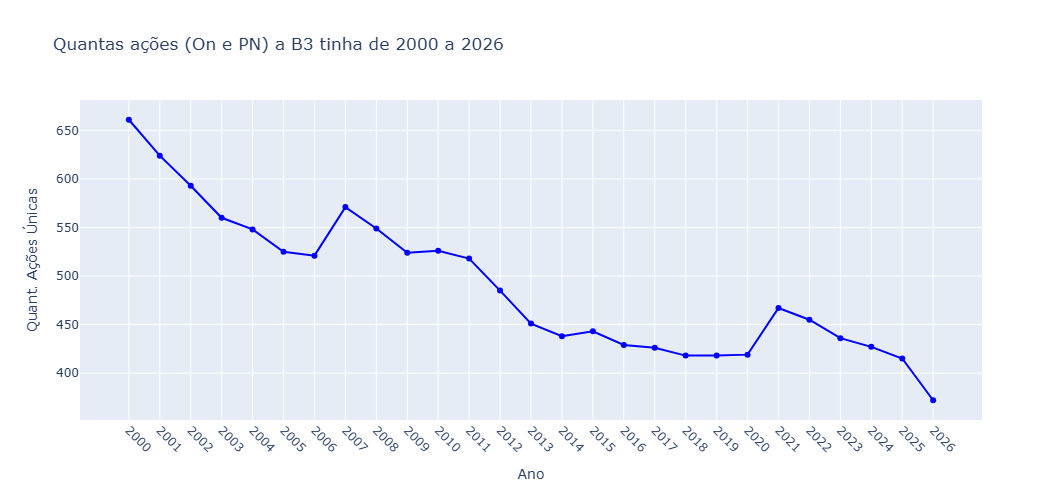

In [ ]:
# mesmo gráfico com plotly graph_objects
#import plotly.graph_objects as go
df = pd.read_csv('b3_analysis/codigos_unicos_acoes/b3_TotalAcoesUnicas_2000-2026.csv')

# Criação da figura
fig = go.Figure()

# Adiciona a série
fig.add_trace(go.Scatter(
    x=df['ano'],
    y=df['tot_acoes'],
    mode='lines+markers',
    name='ações únicas por ano',
    line=dict(color='blue')
))
# Ajusta layout (equivalente ao plt.figure, plt.title, plt.xlabel, plt.ylabel, plt.grid, plt.legend)
fig.update_layout(
    title='Quantas ações (On e PN) a B3 tinha de 2000 a 2026',
    xaxis=dict(
        title='Ano',
        tickangle=45,   # rotação dos rótulos do eixo x
        showgrid=True   # ativa a grade vertical
    ),
    yaxis=dict(
        title='Quant. Ações Únicas',
        showgrid=True   # ativa a grade horizontal
    ),
    legend=dict(
        title='',       # legenda sem título
        orientation='h', # horizontal (pode ser 'v' para vertical)
        x=0.5,
        xanchor='center',
        y=-0.2
    ),
    width=1000,  # equivalente ao figsize=(10,5)
    height=500
)

fig.show()

In [56]:
# salva em excel
stock_code_unique.to_excel("b3_analysis/codigos_unicos_acoes/b3_unique_acoesONPNBR.xlsx")

In [43]:
# quais as ações que são comuns e 'existem' em todos os anos desde 2000?

df = pd.read_csv("b3_analysis/codigos_unicos_acoes/b3_unique_acoesONPNBR_by_year.csv")

# Step 1: Convert each column to a set of unique values
sets_per_column = [set(df[col]) for col in df.columns]

# Step 2: Find the intersection across all sets
common_values = set.intersection(*sets_per_column)

# Step 3: Convert to a list if needed
common_values_list = list(common_values)
num_list = len(common_values_list)

print(sorted(common_values_list))
print(f"quantidade: {num_list}")

['ALPA3', 'ALPA4', 'BAUH4', 'BAZA3', 'BBAS3', 'BBDC3', 'BBDC4', 'BEES3', 'BGIP4', 'BMEB4', 'BMIN4', 'BMKS3', 'BNBR3', 'BRAP3', 'BRAP4', 'BRSR3', 'CBEE3', 'CEBR3', 'CEBR5', 'CEBR6', 'CEEB3', 'CEEB5', 'CLSC3', 'CMIG3', 'CMIG4', 'COCE3', 'COCE5', 'CPLE3', 'CSNA3', 'CTKA4', 'DOHL4', 'EALT4', 'EKTR4', 'EMAE4', 'ESTR4', 'FESA4', 'GEPA3', 'GEPA4', 'GOAU3', 'GOAU4', 'HBTS5', 'ITSA3', 'ITSA4', 'MAPT4', 'MERC4', 'MOAR3', 'MTSA4', 'MYPK3', 'PATI4', 'PETR3', 'PETR4', 'PNVL3', 'PTNT4', 'RANI3', 'ROMI3', 'RPAD3', 'RPAD5', 'RPAD6', 'SBSP3', 'SCAR3', 'SHUL4', 'SOND5', 'SOND6', 'TELB3', 'TELB4', 'TKNO4', 'TUPY3', 'UNIP3', 'UNIP5', 'UNIP6', 'USIM3', 'USIM5', 'VALE3']
quantidade: 73


In [44]:
#salva em txt, os tickers/stock que estão presentes em todos os anos de 2000 a 2026 (73 tickers)

with open('b3_analysis/codigos_unicos_acoes/b3_unicas_AcoesComunsAtodosAnos2026.txt', 'w') as f:
    for item in common_values_list:      
        f.write(f"{item}\n")

In [74]:
# ABAIXO - 3 celulas de código para testar timing usando pandas, pyarrow e parquet
# - abrindo 27 arquivos (b3_data) que, somando, têm 20 milhões de registros 
# maquina com i5 11300H (8 logical cores), 32 GB RAM, SSD
# pandas, lendo arquivos no formato csv: 37,96 seg
# pandas, lendo mesmos arquivos no formato parquet (usando pyarrow): 8.06 seg
# pyarrow lendo 'direto' os mesmos arquivos no formato parquet: 1.62 seg
#=================================================================================

#### calcula o total de registros dos anos disponíveis: de 2000 a 27 fevereiro de 2026
# usando pandas para ver total de registros na pasta csv (20 milhões registros: em 45.23 segundos)
# teste para calcular 'timing' de diferentes bibliotecas

start_time = time.time()
path = "b3_csv/b3_data/"
#arquivos = os.listdir(path)
arquivos = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
tot = 0

for item in arquivos:
    caminho = path + item
    df = pd.read_csv(caminho)
    tot = tot+ df.shape[0]
end_time = time.time() - start_time

print(f" tempo: {end_time:.2f} seg. ; Total geral de registros de 2000 a 27-fev-2026: {tot:,}")

 tempo: 37.96 seg. ; Total geral de registros de 2000 a 27-fev-2026: 20,241,889


In [75]:
#### calcula o total de registros dos anos disponíveis: de 2000 a 27 fevereiro de 2026
# usando pandas para ver total de registros na pasta parquet (20 milhões registros em 8.68 segundos)
# teste para calcular 'timing' de diferentes bibliotecas

start_time = time.time()
path = "b3_parquet/b3_data/"
#arquivos = os.listdir(path)
arquivos = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
tot = 0

for item in arquivos:
    caminho = path + item
    df = pd.read_parquet(caminho)
    tot = tot+df.shape[0]
end_time = time.time() - start_time

print(f" tempo: {end_time:.2f} seg. ; Total geral de registros de 2000 a 27-fev-2026: {tot:,}")

 tempo: 8.06 seg. ; Total geral de registros de 2000 a 27-fev-2026: 20,241,889


In [76]:
#### calcula o total de registros dos anos disponíveis: de 2000 a 27 fev de 2026
# usando pyarrow para ver total de registros na pasta parquet (20 milhões registros em 1.50 segundos)
# teste para calcular 'timing' de diferentes bibliotecas

start_time = time.time()
path = "b3_parquet/b3_data/"
#arquivos = os.listdir(path)
arquivos = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
tot = 0

for item in arquivos:
    caminho = path + item
    num_linhas = pyarrow.parquet.read_table(caminho).num_rows
    tot = tot+num_linhas

end_time = time.time() - start_time

print(f" tempo: {end_time:.2f} seg.; Total geral de registros de 2000 a 27-fev-2026: {tot:,}")

 tempo: 1.62 seg.; Total geral de registros de 2000 a 27-fev-2026: 20,241,889


In [35]:
#calcula a soma de VOLTOT de todos os anos por mercado e monta um dataframe por mercado com total de cada ano

mercados = ['mercado_acaoONPNBR', 'mercado_bdr', 'mercado_FIIs', 'mercado_frac', 'mercado_outros', 'mercado_units', 'mercado_avista']

tipo_arq = 'csv' # ou csv ou pickle

for mercado_def in mercados:
    path = f"b3_{tipo_arq}/{mercado_def}/"
    arquivos = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
    data = []
    vol_final=0
    nome_col = mercado_def[8:]
    
    for arq_ano in arquivos:
        year = arq_ano[-8:-4]
        caminho = path + arq_ano 
        df = pd.read_csv(caminho)
        vol_ano = df['VOLTOT'].sum()
        vol_final += vol_ano
        vol2 = round(vol_ano,2)
        
        #data.append({'ano':year, 'volume': vol2})
        data.append({'ano':year, nome_col: vol2})
        
    df_anos = pd.DataFrame(data)
    #df_anos.rename(columns={'volume': nome_col}, inplace = True)
    
    path2 = f"b3_analysis/volume_{mercado_def}.csv"
    df_anos.to_csv(path2, index=False)
    
    path3 = f"b3_analysis/tot_vol_{mercado_def}.txt"
    with open(path3, 'w') as f:
        f.write(f"{vol_final:,.2f}")


In [36]:
# merge das colunas referente aos volumes financeiros dos diferentes mercados ('join')
# para montar tabela de 2000 2026 com todos 'volumes' de todos os mercados

df_ONPNBR = pd.read_csv('b3_analysis/volume_mercados/volume_mercado_acaoONPNBR.csv')
df_avista = pd.read_csv('b3_analysis/volume_mercados/volume_mercado_avista.csv')
df_bdr = pd.read_csv('b3_analysis/volume_mercados/volume_mercado_bdr.csv')
df_FIIs = pd.read_csv('b3_analysis/volume_mercados/volume_mercado_FIIs.csv')
df_frac = pd.read_csv('b3_analysis/volume_mercados/volume_mercado_frac.csv')
df_outros = pd.read_csv('b3_analysis/volume_mercados/volume_mercado_outros.csv')
df_units = pd.read_csv('b3_analysis/volume_mercados/volume_mercado_units.csv')

todos_mercados_volume2000_2026 = (
    df_ONPNBR
    .merge(df_avista, on="ano", how="left")
    .merge(df_bdr, on="ano", how="left")
    .merge(df_FIIs, on="ano", how="left")
    .merge(df_frac, on="ano", how="left")
    .merge(df_outros, on="ano", how="left")
    .merge(df_units, on="ano", how="left")
)

todos_mercados_volume2000_2026.to_csv('b3_analysis/volume_mercados/todos_mercados_volume2000_2026.csv', index = False)


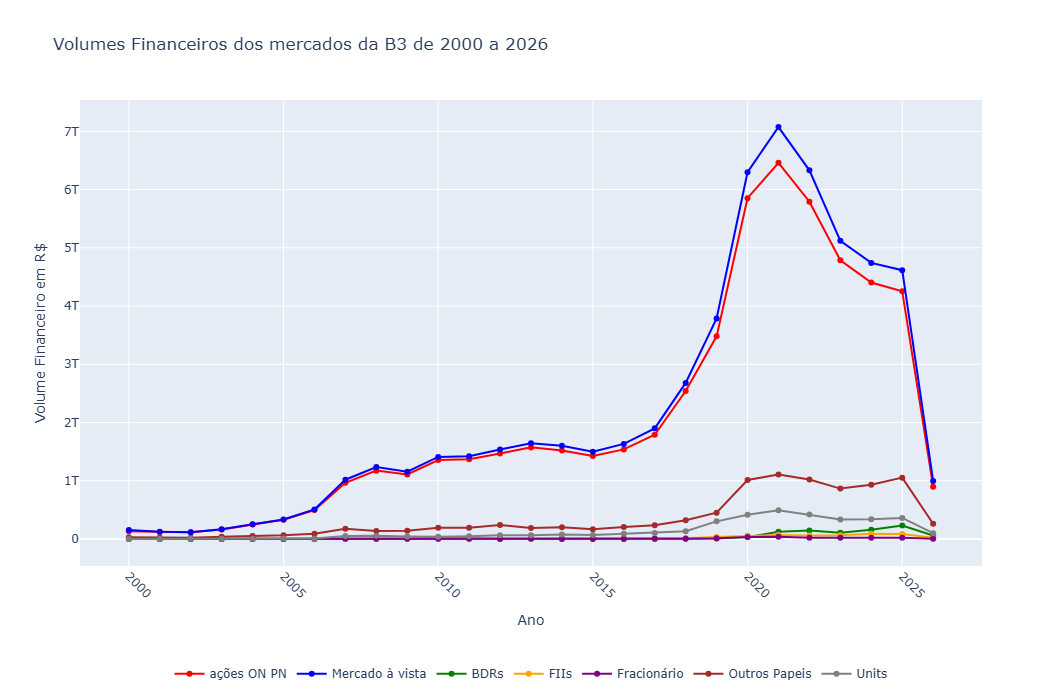

In [65]:
# gráfico com plotly graph_objects (volume financeiro dos mercados da B3 (2000-2026))

df = pd.read_csv('b3_analysis/volume_mercados/todos_mercados_volume2000_2026.csv')

# Criação da figura
fig = go.Figure()

# série acaoONPNBR
fig.add_trace(go.Scatter(
    x=df['ano'],
    y=df['acaoONPNBR'],
    mode='lines+markers',
    name='ações ON PN',
    line=dict(color='red')
))

# série avista
fig.add_trace(go.Scatter(
    x=df['ano'],
    y=df['avista'],
    mode='lines+markers',
    name='Mercado à vista',
    line=dict(color='blue')
))

# série bdr
fig.add_trace(go.Scatter(
    x=df['ano'],
    y=df['bdr'],
    mode='lines+markers',
    name='BDRs',
    line=dict(color='green')
))

# série FIIs
fig.add_trace(go.Scatter(
    x=df['ano'],
    y=df['FIIs'],
    mode='lines+markers',
    name='FIIs',
    line=dict(color='orange')
))

# série frac
fig.add_trace(go.Scatter(
    x=df['ano'],
    y=df['frac'],
    mode='lines+markers',
    name='Fracionário',
    line=dict(color='purple')
))

# série outros
fig.add_trace(go.Scatter(
    x=df['ano'],
    y=df['outros'],
    mode='lines+markers',
    name='Outros Papeis',
    line=dict(color='brown')
))

# série units
fig.add_trace(go.Scatter(
    x=df['ano'],
    y=df['units'],
    mode='lines+markers',
    name='Units',
    line=dict(color='grey')
))

# Ajusta layout (equivalente ao plt.figure, plt.title, plt.xlabel, plt.ylabel, plt.grid, plt.legend)
fig.update_layout(
    title='Volumes Financeiros dos mercados da B3 de 2000 a 2026',
    xaxis=dict(
        title='Ano',
        tickangle=45,   # rotação dos rótulos do eixo x
        showgrid=True,   # ativa a grade vertical
        
    ),
    yaxis=dict(
        title='Volume Financeiro em R$',
        showgrid=True,   # ativa a grade horizontal
        # type='log'     # para ver melhor as alterações nos 'menores volumes'
    ),
    legend=dict(
        title='',       # legenda sem título
        orientation='h', # horizontal (pode ser 'v' para vertical)
        x=0.5,
        xanchor='center',
        y=-0.2
    ),
    width=1000,  # equivalente ao figsize=(10,5)
    height=700
)

fig.show()

In [9]:
# função para ler ranking de acoes do ibov de 202509 e de 202601 em "b3_analysis/b3_rankingTop20/rk_ibov{ano_mes}.csv"
# retorna dataframe com código da ação (codigo) e a porcentagem (porc_indice) do ibov que é referente a essa acao

def leListaRkAcao (ano_mes):
    path_rk = f"b3_analysis/b3_rankingTop20/rk_ibov{ano_mes}.csv"
    df_rk = pd.read_csv(path_rk)
    return df_rk
    

In [13]:
# le (**o ano**, não implementei mes e dia), acao por acao, do mercado_avista  (ou outro mercado)
# 

def leCotAcao(acao, inicio, fim, mercado):
    ano = inicio[:4] #le o ano da string(inicio) AAAA-MM-DD 
    path_onpnbr = f"b3_parquet/{mercado}/{mercado}{ano}.parquet" # vamos usar parquet para agilizar leitura
    df_cotacoes = pd.read_parquet(path_onpnbr)
    #df_cotacoes['DATAPREG'] = pd.to_datetime(df_cotacoes['DATAPREG'], format='%Y-%m-%d')
    selected_col = ['DATAPREG','PREULT']
    df_acao = df_cotacoes[(df_cotacoes['CODNEG']==acao)& (df_cotacoes['DATAPREG'] >= inicio)][selected_col] # de um 'inicio' e vai até acabar (não usei variável 'fim')
    df_acao.to_csv(f"b3_analysis/acoesTop20_cotacoes/top{ano}_{acao}.csv", index=False)
    return

In [20]:
leCotAcao('VBBR3','2025-09-01','a','mercado_acaoONPNBR')

In [ ]:
# lê todas as acoes do ranking de 202602 (lido acima)
# obs: e a BPAC11 que é uma unit (do banco BTG) - lê no mercado_units
df_ranking202602 = pd.read_csv('b3_analysis/b3_rankingTop20/rk_ibov202602.csv')
for acao in df_ranking202602['codigo']:
    print(acao)
    if acao == 'BPAC11':
        leCotAcao(acao,'2026-01-01','a','mercado_units')
    else:
        leCotAcao(acao,'2026-01-01','a','mercado_acaoONPNBR')

In [ ]:
#
# ATENÇÃO - NA PASTA TOP20 DO ANO ***2025*** EMBR3 -> EMBJ3 (EMBRAER MUDOU SIMBOLO) ELET3 -> AXIA3 (ELETROBRAS MUDOU SIMBOLO)
# ficou com top 21 acoes porque SUZB3 e VBBR3 andaram trocando ultimas posicoes

In [63]:
# juntar as top20 de 2025 e 2026 por ticker na pasta top2526
#
#
path_top = f"b3_analysis/acoesTop20_cotacoes/"
lista_arq = [f for f in os.listdir(path_top) if os.path.isfile(os.path.join(path_top, f))]
lista25 = []
lista26 = []
listaTop = []
for item in lista_arq:
    if (item[3:7] == '2025'):
        lista25.append(item)
    elif (item[3:7] == '2026'):
        lista26.append(item)

path2526 = f"b3_analysis/acoesTop20_cotacoes/top2526"

for item1 in lista25:
    for item2 in lista26:
        if item1[8:13] == item2[8:13]:
            df1 = pd.read_csv(f"{path_top}{item1}")
            df2 = pd.read_csv(f"{path_top}{item2}")
            df3 = pd.concat([df1,df2])
            acao = f"{path2526}/{item1[8:13]}.csv"
            
            df3.to_csv(acao, index=False)


In [64]:
caminho_top = "b3_analysis/acoesTop20_cotacoes/top2526"
acoes_files = [f for f in os.listdir(caminho_top) if os.path.isfile(os.path.join(caminho_top, f))]
        
for file in acoes_files:
    df = pd.read_csv(f"b3_analysis/acoesTop20_cotacoes/top2526/{file}")
    acao = file[:-4]
    df['CODNEG'] = acao


In [5]:
# Carregar pesos das TOP 21 ações do IBOV (fevereiro 2026)


ranking_file = 'b3_analysis/b3_rankingTop20/rk_ibov202602.csv'
df_ranking = pd.read_csv(ranking_file)
top21 = df_ranking['codigo'].tolist()
pesos = dict(zip(df_ranking['codigo'], df_ranking['porc_indice'] / 100))  # pesos em decimal

print("TOP 21 ações e seus pesos:")
for acao, peso in pesos.items():
    print(f"{acao}: {peso:.4f}")

TOP 21 ações e seus pesos:
VALE3: 0.1142
ITUB4: 0.0842
PETR4: 0.0580
AXIA3: 0.0416
PETR3: 0.0407
BBDC4: 0.0398
SBSP3: 0.0354
BPAC11: 0.0314
WEGE3: 0.0307
B3SA3: 0.0299
ITSA4: 0.0297
EMBJ3: 0.0274
BBAS3: 0.0264
ABEV3: 0.0250
EQTL3: 0.0205
RDOR3: 0.0189
RENT3: 0.0182
ENEV3: 0.0164
PRIO3: 0.0136
SUZB3: 0.0136


In [6]:
# Carregar cotações das TOP 21 ações

cotacoes_dir = 'b3_analysis/acoesTop20_cotacoes/top2526'
all_files = glob.glob(os.path.join(cotacoes_dir, "*.csv"))

df_cotacoes = {}
for file in all_files:
    acao = os.path.basename(file)[:-4]
    if acao in top21:
        df = pd.read_csv(file)
        df['DATAPREG'] = pd.to_datetime(df['DATAPREG'])
        df.set_index('DATAPREG', inplace=True)
        df_cotacoes[acao] = df['PREULT']

print(f"Carregadas cotações para {len(df_cotacoes)} ações.")

Carregadas cotações para 20 ações.


In [7]:
# Carregar evolução diária do IBOV
def load_ibov_data(year, month=None):
    ibov_dir = 'b3_csv/b3_ibov/ibovEvolucaoDiaria_brcsv'
    if month:
        file = f'Evolucao_Diaria{year}{month:02d}.csv'
    else:
        file = f'Evolucao_Diaria{year}.csv'
    path = os.path.join(ibov_dir, file)
    df = pd.read_csv(path)
    # Pivotar para série temporal
    df_melted = df.melt(id_vars=['Dia'], var_name='Mes', value_name='IBOV')
    df_melted = df_melted.dropna()
    df_melted['Mes_num'] = df_melted['Mes'].map({'Jan':1, 'Fev':2, 'Mar':3, 'Abr':4, 'Mai':5, 'Jun':6, 'Jul':7, 'Ago':8, 'Set':9, 'Out':10, 'Nov':11, 'Dez':12})
    df_melted['Data'] = pd.to_datetime(f'{year}-' + df_melted['Mes_num'].astype(str) + '-' + df_melted['Dia'].astype(str))
    df_melted.set_index('Data', inplace=True)
    return df_melted['IBOV']

# Carregar dados de 2025 e 2026
ibov_2025 = load_ibov_data(2025)
ibov_2026 = load_ibov_data(2026, 2)
ibov = pd.concat([ibov_2025, ibov_2026]).sort_index()

print(f"IBOV carregado de {ibov.index.min()} a {ibov.index.max()}")

IBOV carregado de 2025-01-02 00:00:00 a 2026-02-27 00:00:00


In [8]:
# Calcular retornos diários
retornos_acoes = {}
for acao, preco in df_cotacoes.items():
    retornos_acoes[acao] = preco.pct_change()

retorno_ibov = ibov.pct_change()

# Calcular retorno ponderado das TOP 21
df_retornos = pd.DataFrame(retornos_acoes)
df_retornos = df_retornos.dropna()  # remover dias sem dados para todas

# Aplicar pesos
retorno_top21 = (df_retornos * pd.Series(pesos)).sum(axis=1)

print("Retornos calculados.")

Retornos calculados.


In [9]:
# Calcular retornos acumulados
retorno_top21_acum = (1 + retorno_top21).cumprod() - 1
retorno_ibov_acum = (1 + retorno_ibov).cumprod() - 1

# Combinar em um DataFrame para plotar
df_plot = pd.DataFrame({
    'IBOV': retorno_ibov_acum,
    'TOP21': retorno_top21_acum
}).dropna()

# Gráfico com Plotly
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['IBOV'], mode='lines', name='IBOV'))
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['TOP21'], mode='lines', name='TOP 21 Ações'))
fig.update_layout(title='Retorno Acumulado: IBOV vs TOP 21 Ações',
                  xaxis_title='Data',
                  yaxis_title='Retorno Acumulado')
fig.show()

# Calcular contribuição: diferença entre IBOV e TOP21
contribuicao = df_plot['IBOV'] - df_plot['TOP21']
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=contribuicao.index, y=contribuicao, mode='lines', name='Contribuição das Outras Ações'))
fig2.update_layout(title='Diferença no Retorno Acumulado (IBOV - TOP21)',
                   xaxis_title='Data',
                   yaxis_title='Diferença')
fig2.show()

In [10]:
# Calcular correlação entre retornos diários do TOP21 e IBOV
# Combinar retornos em um DataFrame
df_retornos_combinados = pd.DataFrame({
    'TOP21': retorno_top21,
    'IBOV': retorno_ibov
}).dropna()

correlacao = df_retornos_combinados['TOP21'].corr(df_retornos_combinados['IBOV'])
print(f"Correlação de Pearson entre retornos diários do TOP21 e IBOV: {correlacao:.4f}")

# Gráfico scatter plot com linha de regressão
import plotly.express as px

fig_corr = px.scatter(df_retornos_combinados, x='TOP21', y='IBOV', trendline='ols',
                      title=f'Correlação entre Retornos Diários: TOP21 vs IBOV (Corr = {correlacao:.4f})',
                      labels={'TOP21': 'Retorno Diário TOP21', 'IBOV': 'Retorno Diário IBOV'})
fig_corr.show()

Correlação de Pearson entre retornos diários do TOP21 e IBOV: 0.9756


In [12]:
# Criar gráfico de influência das TOP 21 ações no IBOV, similar ao analise_influencia_top20_ibov.py

# Definir período inicial como 2025-09-01
DATE_INI = pd.Timestamp("2025-09-01")

# Filtrar IBOV a partir de DATE_INI
ibov_filtrado = ibov[ibov.index >= DATE_INI]

# Calcular contribuições individuais no período filtrado
retornos_individuais = {}
for acao in top21:
    if acao in df_cotacoes:
        preco = df_cotacoes[acao]
        preco_filtrado = preco[preco.index >= DATE_INI]
        if not preco_filtrado.empty:
            ret = (preco_filtrado.iloc[-1] - preco_filtrado.iloc[0]) / preco_filtrado.iloc[0] * 100
            retornos_individuais[acao] = ret

# Contribuição em p.p. = retorno * peso / 100
contribuicoes = {}
for acao in top21:
    if acao in retornos_individuais:
        contrib = retornos_individuais[acao] * pesos[acao]
        contribuicoes[acao] = contrib

df_contrib = pd.DataFrame(list(contribuicoes.items()), columns=['ticker', 'contribuicao_pp'])
df_contrib = df_contrib.sort_values('contribuicao_pp', ascending=False)

# Retorno do IBOV no período filtrado
retorno_ibov_total = (ibov_filtrado.iloc[-1] - ibov_filtrado.iloc[0]) / ibov_filtrado.iloc[0] * 100

# Soma das contribuições
soma_contrib = df_contrib['contribuicao_pp'].sum()

# Gráfico com subplots
from plotly.subplots import make_subplots

cores_contrib = ["#2ecc71" if v >= 0 else "#e74c3c" for v in df_contrib["contribuicao_pp"]]

fig_influencia = make_subplots(
    rows=3, cols=1,
    subplot_titles=(
        "Contribuição de cada ação TOP21 para a variação do IBOV (p.p.)",
        "Retorno individual das ações × Peso no índice",
        "IBOV diário no período",
    ),
    row_heights=[0.38, 0.35, 0.27],
    vertical_spacing=0.12,
)

# Subplot 1: contribuição em p.p.
fig_influencia.add_trace(
    go.Bar(
        x=df_contrib["ticker"],
        y=df_contrib["contribuicao_pp"],
        marker_color=cores_contrib,
        text=[f"{v:+.2f} p.p." for v in df_contrib["contribuicao_pp"]],
        textposition="outside",
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Contribuição: %{y:+.3f} p.p.<br>"
            "<extra></extra>"
        ),
        cliponaxis=False,
        name="Contribuição (p.p.)",
    ),
    row=1, col=1,
)

# Linha da variação real do IBOV
fig_influencia.add_hline(
    y=retorno_ibov_total, line_dash="dash", line_color="#2980b9", line_width=2,
    annotation_text=f"IBOV real: {retorno_ibov_total:+.2f}%",
    annotation_position="top right",
    row=1, col=1,
)

# Linha da soma das contribuições
fig_influencia.add_hline(
    y=soma_contrib, line_dash="dot", line_color="#8e44ad", line_width=2,
    annotation_text=f"Σ contribuições TOP21: {soma_contrib:+.2f} p.p.",
    annotation_position="bottom right",
    row=1, col=1,
)

# Subplot 2: retorno vs peso (bubble)
df_bubble = pd.DataFrame({
    'ticker': list(retornos_individuais.keys()),
    'retorno_pct': list(retornos_individuais.values()),
    'peso_medio': [pesos[acao] for acao in retornos_individuais.keys()],
    'contribuicao_pp': [contribuicoes[acao] for acao in retornos_individuais.keys()]
})

fig_influencia.add_trace(
    go.Scatter(
        x=df_bubble["retorno_pct"],
        y=df_bubble["peso_medio"],
        mode="markers+text",
        text=df_bubble["ticker"],
        textposition="top center",
        textfont=dict(size=10),
        marker=dict(
            size=df_bubble["contribuicao_pp"].abs() * 12,
            color=df_bubble["contribuicao_pp"],
            colorscale="RdYlGn",
            showscale=True,
            colorbar=dict(
                title="Contrib. (p.p.)",
                x=1.02,
                len=0.33,
                y=0.52,
            ),
            line=dict(color="white", width=1),
        ),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Retorno: %{x:+.2f}%<br>"
            "Peso médio: %{y:.2f}%<br>"
            "<extra></extra>"
        ),
        name="Retorno vs Peso",
    ),
    row=2, col=1,
)
fig_influencia.add_vline(x=0, line_color="grey", line_dash="dot", row=2, col=1)

# Subplot 3: IBOV diário
fig_influencia.add_trace(
    go.Scatter(
        x=ibov_filtrado.index,
        y=ibov_filtrado.values,
        mode="lines",
        line=dict(color="#2980b9", width=2),
        fill="tozeroy",
        fillcolor="rgba(41,128,185,0.12)",
        hovertemplate="Data: %{x|%d/%m/%Y}<br>IBOV: %{y:,.0f}<extra></extra>",
        name="IBOV",
    ),
    row=3, col=1,
)

# Layout global
pct_explicado = soma_contrib / retorno_ibov_total * 100 if retorno_ibov_total != 0 else 0

fig_influencia.update_layout(
    title={
        "text": (
            f"Influência das Ações TOP21 na Valorização do IBOV<br>"
            f"<sup>Período: {ibov_filtrado.index[0].date()} → {ibov_filtrado.index[-1].date()} | IBOV: {retorno_ibov_total:+.2f}% real | "
            f"TOP21 explicam {pct_explicado:.1f}% ({soma_contrib:+.2f} p.p.)</sup>"
        ),
        "x": 0.5, "xanchor": "center", "font": {"size": 18},
    },
    template="plotly_white",
    height=950,
    showlegend=False,
    margin=dict(l=70, r=130, t=110, b=60),
)

fig_influencia.update_xaxes(tickangle=-35, tickfont=dict(size=11), row=1, col=1)
fig_influencia.update_yaxes(ticksuffix=" p.p.", row=1, col=1)
fig_influencia.update_xaxes(title_text="Retorno da ação (%)", ticksuffix="%", row=2, col=1)
fig_influencia.update_yaxes(title_text="Peso no IBOV (%)", ticksuffix="%", row=2, col=1)
fig_influencia.update_xaxes(title_text="Data", tickformat="%b/%Y", row=3, col=1)
fig_influencia.update_yaxes(title_text="Pontos", tickformat=",.0f", row=3, col=1)

fig_influencia.show()